# M12 — Hidden states, emissions, and the meaning of an event

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PM01](../../curriculum/papers/modeling.md#pm01).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** How would predicting a measured task label differ from inferring an unobserved event state?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Original guided lab · 75–100 minutes.** Read 20 min, predict/code 35 min, failure investigation 20 min, explain and transfer 15 min. Run all cells in order in a fresh kernel. All executed data are synthetic unless explicitly stated. No network, GPU, or external dataset is required.

A hidden Markov model separates a latent state from the noisy measurement associated with it. A transition matrix describes how states evolve, and an emission model describes observations conditional on a state. The hidden state can persist even when one noisy measurement looks unusual. This is different from classifying every time point independently.

Filtering estimates the current state using observations available up to that time. Smoothing uses the whole observation sequence, including future observations. Viterbi decoding chooses one most-probable state sequence under the model. These are different outputs and should not be called interchangeable state estimates. The lab implements filtering with known transition and emission parameters so that every probability update is inspectable. It does not fit those parameters by expectation maximization.

At each time, transition probabilities propagate the previous belief to a prior over the next state. Multiplying by emission likelihoods incorporates the new measurement, and normalization gives a probability vector. Log probabilities and log-sum-exp avoid underflow when many likelihood terms are combined. Check that probabilities sum to one and that the transition rows sum to one before interpreting a state plot.

We simulate a two-state process with persistent states and Gaussian measurements around two different means. The filtered state classification should usually recover the true state. This success depends on our deliberately correct model and well-separated emissions. Real fMRI introduces hemodynamic smoothing, physiological artifacts, individual variation, and uncertain model order. An apparent state transition can reflect any combination of these rather than a discrete change in cognition.

BrainIAK's event-segmentation model used in naturalistic analyses imposes structured progression through events. It is not identical to this freely switching two-state HMM. Event counts, allowed transitions, and emission representations are substantive assumptions. Comparing boundaries with behavioral annotations requires an independent or appropriately evaluated comparison rather than choosing the event count to match the desired boundaries after inspection.

The failure experiment shuffles observations in time. Their histogram is unchanged, but the persistent-transition model gives a poorer sequence likelihood. This shows that preserving marginal values is insufficient for a temporal model. It does not establish that every lower likelihood reflects a scientific defect; model misspecification can also produce poor fit. Ask AI to state whether it is fitting parameters, filtering states, smoothing states, or selecting a sequence, and to identify exactly which observations each result can access.

## Transformation contract

Known transition/emission parameters plus time-ordered observations → recursive normalized state probabilities and sequence log likelihood. Filtering retains uncertainty over states; argmax state labels discard that uncertainty.

## Ask your AI tutor

```text
Explain this notebook one transformation at a time.
Before each cell ask me to predict shapes, units, and a check.
Give edits in executable cells of at most 20 lines.
Keep the prescribed split, random seed, and tests intact.
Distinguish generated suggestions from executed results.
After the failure experiment, ask me to explain the mechanism.
```

In [1]:
import numpy as np
from scipy.special import logsumexp
rng=np.random.default_rng(412)
T=np.array([[.97,.03],[.03,.97]]);means=np.array([-1.,1.]);sigma=.65
state=np.zeros(350,dtype=int)
for t in range(1,len(state)):state[t]=rng.choice(2,p=T[state[t-1]])
y=means[state]+rng.normal(0,sigma,len(state))
assert np.allclose(T.sum(axis=1),1)
def filter_hmm(obs):
    logp=np.log(np.array([.5,.5]));probs=[];evidence=0.
    for value in obs:
        prior=logsumexp(logp[:,None]+np.log(T),axis=0)
        emission=-.5*((value-means)/sigma)**2-np.log(sigma*np.sqrt(2*np.pi))
        unnorm=prior+emission;normalizer=logsumexp(unnorm)
        logp=unnorm-normalizer;evidence+=normalizer;probs.append(np.exp(logp))
    return np.array(probs),evidence
p,ll=filter_hmm(y)
print('Filtering state accuracy / sequence log likelihood:',np.mean(p.argmax(axis=1)==state),ll)
assert np.allclose(p.sum(axis=1),1) and np.mean(p.argmax(axis=1)==state)>.9


Filtering state accuracy / sequence log likelihood: 0.9971428571428571 -355.6853428323161


Time-scrambled likelihood: -724.6319638017659


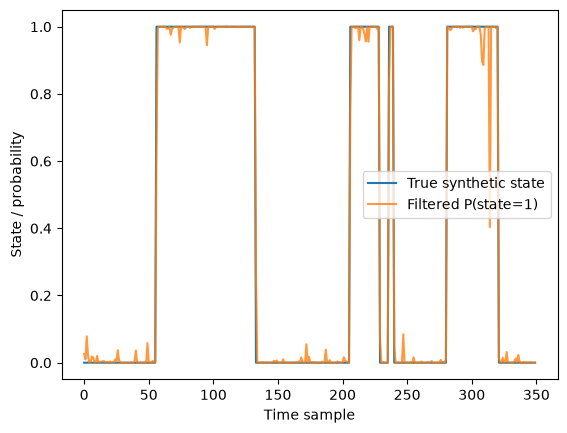

In [2]:
shuffled=rng.permutation(y)
_,bad_ll=filter_hmm(shuffled)
print('Time-scrambled likelihood:',bad_ll)
assert np.array_equal(np.sort(y),np.sort(shuffled)) and bad_ll<ll
import matplotlib.pyplot as plt
plt.plot(state,label='True synthetic state');plt.plot(p[:,1],label='Filtered P(state=1)',alpha=.8)
plt.xlabel('Time sample');plt.ylabel('State / probability');plt.legend();plt.show()


## Deliberate failure and repair

Time permutation preserves the value distribution and destroys persistence. Repair a mistakenly reordered sequence using timestamps, not a favorable fit. A second interpretive failure would label our model a fitted BrainIAK event segmentation: neither its estimation procedure nor its transition constraints were executed.

## Your investigation

Write filtering, smoothing, and Viterbi on three separate arrows and list the observations available to each. Inspect the vendored NMA HMM tutorial, then compare its transition assumptions with BrainIAK EventSegment. Plan how to select the number of events using training data and evaluate boundaries on independent information.

## Transfer to real neuroimaging

The external event-segmentation tutorials use actual naturalistic responses, event-count selection, and boundary comparisons. They are the real-data continuation. The core demonstrates known-parameter inference and cannot be cited as having fitted those external models or analyzed their datasets.

**Primary teaching sources, pinned where hosted on GitHub:**

- [NMA: HMM (vendored)](https://github.com/NeuromatchAcademy/course-content/blob/44634e960df7a14cd0bf7398187f2d209d26b0e8/tutorials/W3D3_HiddenDynamics/student/W3D3_Tutorial2.ipynb)
- [BrainIAK: event segmentation](https://github.com/brainiak/brainiak-tutorials/blob/fb62ede943d9694fe703aee0df5f43ecf5558415/tutorials/12-hmm.ipynb)
- [Dartmouth/OHBM: event segmentation](https://github.com/naturalistic-data-analysis/naturalistic_data_analysis/blob/88bd22741508b4d678202bde7530cee0511e283f/content/Event_Segmentation.ipynb)

Pinned upstream tutorials are a separate assignment; they have **not been executed** by this core lab. They may require data downloads, specialist dependencies, unfinished student cells, and additional compute.

## Exit questions and answer key

1. Does filtering use future observations? **No; smoothing does.**
2. Why is a histogram-preserving shuffle harmful here? **It changes the transition structure that contributes to sequence likelihood.**

### Return to the research question

Reopen [PM01](../../curriculum/papers/modeling.md#pm01) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
